In [1]:
# ---------------------------------------------------------------
# STEP 1: IMPORT LIBRARIES
# ---------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')
#%matplotlib notebook
#%matplotlib inline
%matplotlib widget

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# ---------------------------------------------------------------
# STEP 2: LOAD DATASET
# Why: We load the raw transaction data to begin processing.
# ---------------------------------------------------------------
df = pd.read_csv('bank_transactions.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1048567, 9)

First 5 rows:
  TransactionID CustomerID CustomerDOB CustGender CustLocation  \
0            T1   C5841053     10/1/94          F   JAMSHEDPUR   
1            T2   C2142763      4/4/57          M      JHAJJAR   
2            T3   C4417068    26/11/96          F       MUMBAI   
3            T4   C5342380     14/9/73          F       MUMBAI   
4            T5   C9031234     24/3/88          F  NAVI MUMBAI   

   CustAccountBalance TransactionDate  TransactionTime  \
0            17819.05          2/8/16           143207   
1             2270.69          2/8/16           141858   
2            17874.44          2/8/16           142712   
3           866503.21          2/8/16           142714   
4             6714.43          2/8/16           181156   

   TransactionAmount (INR)  
0                     25.0  
1                  27999.0  
2                    459.0  
3                   2060.0  
4                   1762.5  

Column Info:
<class 'pandas.core.fra

In [3]:
# ---------------------------------------------------------------
# STEP 3: DATA PREPROCESSING
# Why: Raw data has missing values and wrong date formats.
#      We must clean it before computing RFM scores.
# ---------------------------------------------------------------

# Rename column for easier access
df.rename(columns={'TransactionAmount (INR)': 'TransactionAmount'}, inplace=True)


# Convert TransactionDate to datetime format
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], dayfirst=True, errors='coerce')

# Drop rows with missing CustomerID or TransactionDate (cannot compute RFM without these)
df.dropna(subset=['CustomerID', 'TransactionDate'], inplace=True)

# Drop rows with zero or negative transaction amounts
df = df[df['TransactionAmount'] > 0]

print("\nCleaned Dataset Shape:", df.shape)
print("Date range:", df['TransactionDate'].min(), "to", df['TransactionDate'].max())

df = df.sample(n=100000, random_state=42)
print("Using sample size:", len(df))


Cleaned Dataset Shape: (1047732, 9)
Date range: 2016-08-01 00:00:00 to 2016-10-21 00:00:00
Using sample size: 100000


In [4]:
# ---------------------------------------------------------------
# STEP 4: COMPUTE RFM SCORES
# Why: RFM summarises each customer's behaviour into 3 numbers.
#      R = how recently, F = how often, M = how much
# ---------------------------------------------------------------

# Set reference date as the day after the last transaction in the dataset
reference_date = df['TransactionDate'].max() + pd.Timedelta(days=1)
print("\nReference date for Recency calculation:", reference_date)

# Aggregate by CustomerID
rfm = df.groupby('CustomerID').agg(
    Recency=('TransactionDate', lambda x: (reference_date - x.max()).days),
    Frequency=('TransactionID', 'count'),
    Monetary=('TransactionAmount', 'sum')
).reset_index()

print("\nRFM Table (first 10 rows):")
print(rfm.head(10))
print("\nRFM Summary Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())


Reference date for Recency calculation: 2016-10-22 00:00:00

RFM Table (first 10 rows):
  CustomerID  Recency  Frequency  Monetary
0   C1010011       74          1     356.0
1   C1010066       77          1    1200.0
2   C1010072       41          1    3510.0
3   C1010089       65          1     376.0
4   C1010117       75          1     840.0
5   C1010212       49          1     431.0
6   C1010238       78          1    4615.0
7   C1010245       30          1     300.0
8   C1010253       73          1   21968.0
9   C1010274       55          1     560.0

RFM Summary Statistics:
            Recency     Frequency       Monetary
count  98329.000000  98329.000000   98329.000000
mean      57.688373      1.016994    1598.224030
std       15.195608      0.131124    5957.683347
min        1.000000      1.000000       0.010000
25%       46.000000      1.000000     168.850000
50%       58.000000      1.000000     479.000000
75%       71.000000      1.000000    1240.000000
max       82.000000  

In [5]:
# ---------------------------------------------------------------
# STEP 5: HANDLE OUTLIERS
# Why: Extreme values can distort cluster formation.
#      We cap at the 99th percentile to reduce skewness.
# ---------------------------------------------------------------
for col in ['Recency', 'Frequency', 'Monetary']:
    upper = rfm[col].quantile(0.99)
    rfm[col] = rfm[col].clip(upper=upper)

print("\nRFM after outlier capping:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())


RFM after outlier capping:
            Recency     Frequency      Monetary
count  98329.000000  98329.000000  98329.000000
mean      57.688373      1.016760   1351.481721
std       15.195608      0.128372   2829.762425
min        1.000000      1.000000      0.010000
25%       46.000000      1.000000    168.850000
50%       58.000000      1.000000    479.000000
75%       71.000000      1.000000   1240.000000
max       82.000000      2.000000  20000.000000


In [6]:
# ---------------------------------------------------------------
# STEP 6: NORMALISE RFM VALUES
# Why: K-Means uses distance calculations.
#      Variables on different scales bias the clusters.
#      StandardScaler brings all to mean=0, std=1.
# ---------------------------------------------------------------
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("\nNormalised RFM (first 5 rows):")
print(rfm_scaled.head())


Normalised RFM (first 5 rows):
    Recency  Frequency  Monetary
0  1.073449  -0.130559 -0.351792
1  1.270876  -0.130559 -0.053532
2 -1.098242  -0.130559  0.762795
3  0.481170  -0.130559 -0.344724
4  1.139258  -0.130559 -0.180752


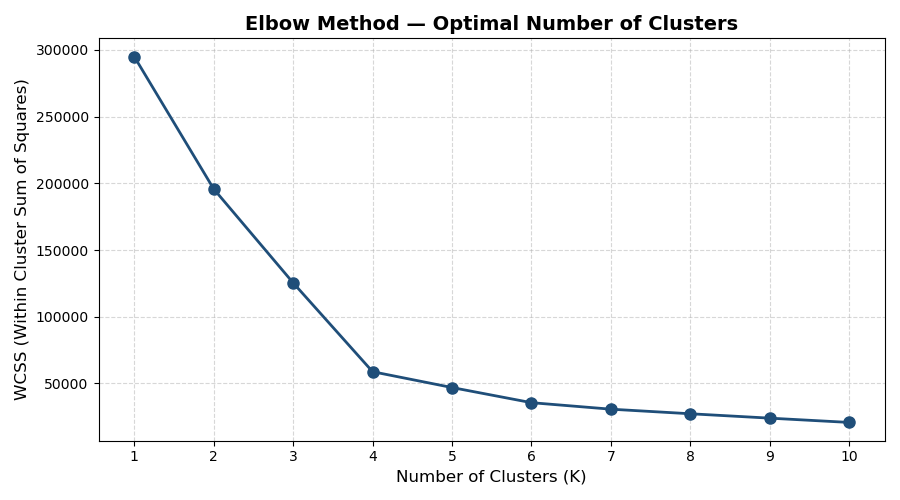


Elbow plot saved as elbow_plot.png


In [7]:
# ---------------------------------------------------------------
# STEP 7: ELBOW METHOD — FIND OPTIMAL K
# Why: K-Means needs K defined upfront.
#      The Elbow Method finds the best K by plotting WCSS vs K.
#      The "elbow" point is where adding more clusters stops helping.
# ---------------------------------------------------------------
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, marker='o', color='#1F4E79', linewidth=2, markersize=8)
plt.title('Elbow Method — Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nElbow plot saved as elbow_plot.png")

In [8]:
# ---------------------------------------------------------------
# STEP 8: RUN K-MEANS CLUSTERING
# Why: Now that we know K, we run K-Means to assign
#      each customer to a cluster based on their RFM scores.
# Change K below based on what the Elbow plot shows.
# ---------------------------------------------------------------
K = 4  # Change this based on your Elbow plot observation

kmeans = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"\nK-Means completed with K={K}")
print("\nCustomers per cluster:")
print(rfm['Cluster'].value_counts().sort_index())



K-Means completed with K=4

Customers per cluster:
Cluster
0    45441
1    48234
2     1648
3     3006
Name: count, dtype: int64


In [9]:
# ---------------------------------------------------------------
# STEP 9: EVALUATE CLUSTER QUALITY
# Why: We need objective measures to confirm our clusters are good.
#      Silhouette Score: closer to 1 = better separated clusters
#      Davies-Bouldin Index: closer to 0 = better compact clusters
# ---------------------------------------------------------------
sil_score = silhouette_score(rfm_scaled, rfm['Cluster'])
db_score = davies_bouldin_score(rfm_scaled, rfm['Cluster'])

print(f"\nCluster Evaluation Metrics:")
print(f"  Silhouette Score:       {sil_score:.4f}  (higher is better, max=1.0)")
print(f"  Davies-Bouldin Index:   {db_score:.4f}  (lower is better, min=0.0)")


Cluster Evaluation Metrics:
  Silhouette Score:       0.5389  (higher is better, max=1.0)
  Davies-Bouldin Index:   0.5400  (lower is better, min=0.0)


In [10]:
# ---------------------------------------------------------------
# STEP 10: PROFILE AND LABEL CLUSTERS
# Why: We need to understand what each cluster represents
#      so we can give business meaning to the segments.
# ---------------------------------------------------------------
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
cluster_profile['Customer_Count'] = rfm['Cluster'].value_counts().sort_index()

print("\nCluster Profile (mean RFM values per cluster):")
print(cluster_profile)

# Label clusters based on RFM profile
# Note: Labels may need adjustment based on your actual cluster profiles
def label_cluster(row):
    if row['Monetary'] > cluster_profile['Monetary'].median() and row['Frequency'] > cluster_profile['Frequency'].median():
        return 'Champions'
    elif row['Recency'] < cluster_profile['Recency'].median() and row['Frequency'] > cluster_profile['Frequency'].median():
        return 'Loyal Customers'
    elif row['Recency'] > cluster_profile['Recency'].median() and row['Monetary'] > cluster_profile['Monetary'].median():
        return 'At-Risk Customers'
    else:
        return 'One-Time / Lost'

cluster_profile['Segment_Label'] = cluster_profile.apply(label_cluster, axis=1)
rfm['Segment'] = rfm['Cluster'].map(cluster_profile['Segment_Label'])

print("\nFinal Cluster Labels:")
print(cluster_profile[['Recency', 'Frequency', 'Monetary', 'Customer_Count', 'Segment_Label']])



Cluster Profile (mean RFM values per cluster):
         Recency  Frequency  Monetary  Customer_Count
Cluster                                              
0          44.44        1.0    897.97           45441
1          70.41        1.0    904.57           48234
2          49.51        2.0   2702.03            1648
3          58.32        1.0  14637.72            3006

Final Cluster Labels:
         Recency  Frequency  Monetary  Customer_Count      Segment_Label
Cluster                                                                 
0          44.44        1.0    897.97           45441    One-Time / Lost
1          70.41        1.0    904.57           48234    One-Time / Lost
2          49.51        2.0   2702.03            1648          Champions
3          58.32        1.0  14637.72            3006  At-Risk Customers


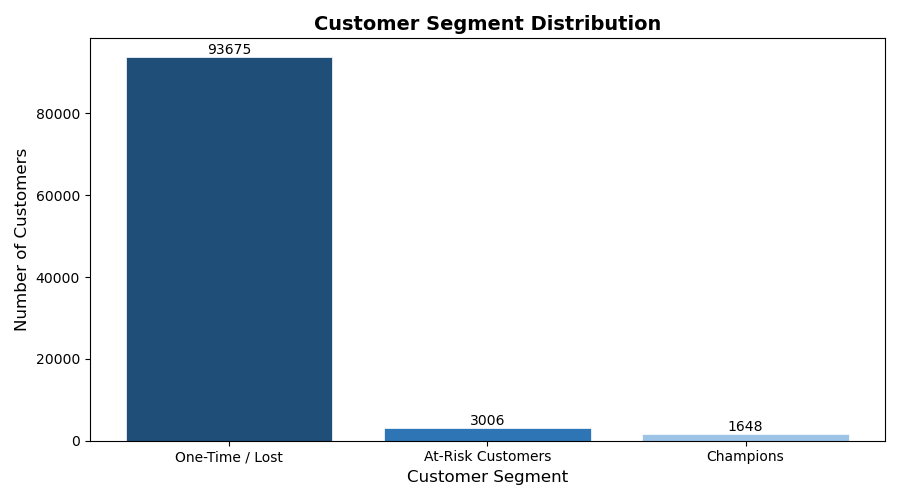

Cluster distribution chart saved as cluster_distribution.png


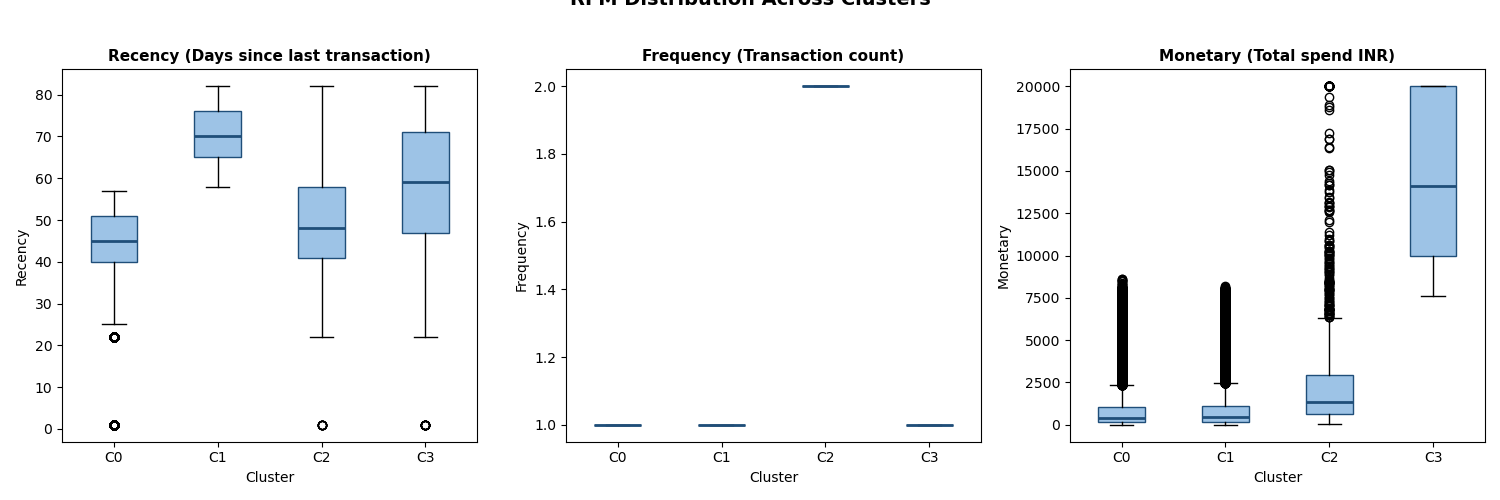

RFM boxplots saved as rfm_boxplots.png


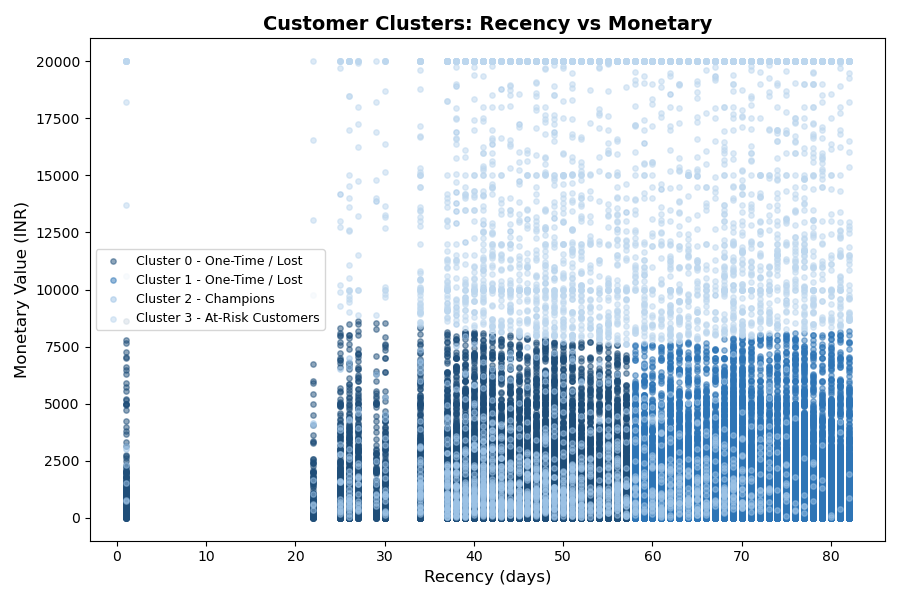

Scatter plot saved as scatter_clusters.png


In [11]:
# ---------------------------------------------------------------
# STEP 11: VISUALISATIONS
# Why: Charts help communicate results clearly in the paper.
# ---------------------------------------------------------------

colors = ['#1F4E79', '#2E75B6', '#9DC3E6', '#BDD7EE']

# Chart 1: Cluster Distribution Bar Chart
plt.figure(figsize=(9, 5))
segment_counts = rfm['Segment'].value_counts()
bars = plt.bar(segment_counts.index, segment_counts.values, color=colors[:len(segment_counts)], edgecolor='white', linewidth=0.5)
plt.title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
for bar, val in zip(bars, segment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Cluster distribution chart saved as cluster_distribution.png")

# Chart 2: RFM Feature Comparison Across Clusters
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Recency', 'Frequency', 'Monetary']
titles = ['Recency (Days since last transaction)', 'Frequency (Transaction count)', 'Monetary (Total spend INR)']

for ax, metric, title in zip(axes, metrics, titles):
    cluster_vals = [rfm[rfm['Cluster'] == c][metric].values for c in sorted(rfm['Cluster'].unique())]
    ax.boxplot(cluster_vals, patch_artist=True,
               boxprops=dict(facecolor='#9DC3E6', color='#1F4E79'),
               medianprops=dict(color='#1F4E79', linewidth=2))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel(metric)
    ax.set_xticklabels([f'C{c}' for c in sorted(rfm['Cluster'].unique())])

plt.suptitle('RFM Distribution Across Clusters', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfm_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("RFM boxplots saved as rfm_boxplots.png")

# Chart 3: Scatter Plot — Recency vs Monetary coloured by Cluster
plt.figure(figsize=(9, 6))
for i, cluster in enumerate(sorted(rfm['Cluster'].unique())):
    subset = rfm[rfm['Cluster'] == cluster]
    plt.scatter(subset['Recency'], subset['Monetary'], label=f"Cluster {cluster} - {cluster_profile.loc[cluster, 'Segment_Label']}", alpha=0.5, s=15, color=colors[i % len(colors)])
plt.title('Customer Clusters: Recency vs Monetary', fontsize=14, fontweight='bold')
plt.xlabel('Recency (days)', fontsize=12)
plt.ylabel('Monetary Value (INR)', fontsize=12)
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig('scatter_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved as scatter_clusters.png")

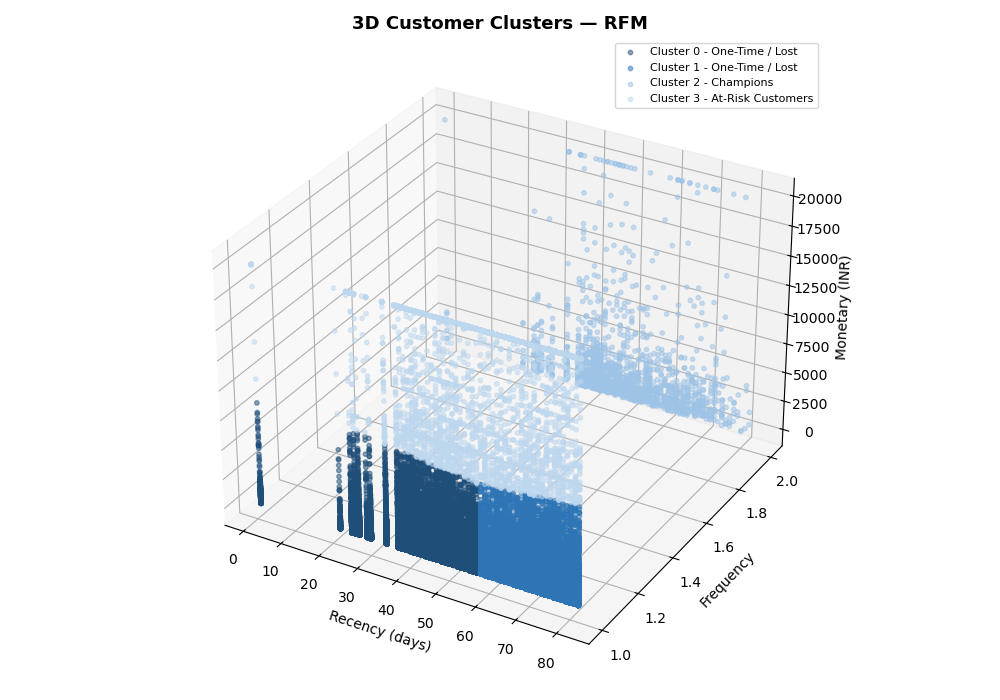

3D plot saved as 3d_clusters.png


In [12]:
# ---------------------------------------------------------------
# STEP 12: 3D Plot
# Why: The regular scatter plot only shows 2 dimensions. 
#      The 3D plot shows all R, F and M together
# ---------------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = ['#1F4E79', '#2E75B6', '#9DC3E6', '#BDD7EE']

for i, cluster in enumerate(sorted(rfm['Cluster'].unique())):
    subset = rfm[rfm['Cluster'] == cluster]
    ax.scatter(
        subset['Recency'],
        subset['Frequency'],
        subset['Monetary'],
        label=f"Cluster {cluster} - {cluster_profile.loc[cluster, 'Segment_Label']}",
        color=colors[i % len(colors)],
        alpha=0.5,
        s=10
    )

ax.set_xlabel('Recency (days)', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)
ax.set_zlabel('Monetary (INR)', fontsize=10)
ax.set_title('3D Customer Clusters — RFM', fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('3d_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("3D plot saved as 3d_clusters.png")

In [13]:
# ---------------------------------------------------------------
# STEP 13: SAVE FINAL RESULTS
# Why: Save the RFM + cluster output to CSV for reference.
# ---------------------------------------------------------------
rfm.to_csv('rfm_customer_segments.csv', index=False)
print("\nFinal customer segments saved to rfm_customer_segments.csv")

print("\n" + "="*60)
print("ALL STEPS COMPLETE")
print(f"Total customers segmented: {len(rfm)}")
print(f"Number of clusters: {K}")
print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Index: {db_score:.4f}")
print("="*60)


Final customer segments saved to rfm_customer_segments.csv

ALL STEPS COMPLETE
Total customers segmented: 98329
Number of clusters: 4
Silhouette Score: 0.5389
Davies-Bouldin Index: 0.5400
